In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Easy

**Точечное изображение** — это математическая модель динамической системы с дискретным временем, заданная рекуррентным соотношением:
$$\vec{x}_{n+1} = \vec{f}(\vec{x}_{n}),$$
где $\vec{x}_{n}$ — вектор состояния в момент $n$, $\vec{f}$ — отображение,
определяющее переход к следующему состоянию.

Для задания рассмотрим одномерное логистическое отображение:
$$x_{n+1} = rx_n(1 - x_n), x \in (0, 1) \ r \in (0, 4]$$

#### Easy:

Докажите, что $\forall n \in \mathbb{N}, \forall r \in (0;1]$
$$0 < x_0 < 1 \Longrightarrow 0 < x_n < 1$$

---

Докажем утверждение с помощью метода математической индукции.

База индукции:
$$0 < x_0 < 1$$
 $$x_1 = rx_0(1 - x_0)$$
 $$0 < x_0 \Longrightarrow r * 0 * 1 = 0 < x_1$$
 $$0 < x_0 < 1 \Longleftrightarrow 1 > 1 - x_0 > 0 \Rightarrow x_1 < r * 1 * 1 < r < 1$$
 $$0 < x_1 < 1$$

Индукционный переход:

По аналогии с "База индукции" доказывается, что
$$0 < x_n < 1 \Longrightarrow 0 < x_{n+1} < 1$$

---

#### Easy:

Сделайте вывод: как параметр $r$ влияет на поведение функции зависимости $x_n$ от $x_{n−1}$? Постройте эту функцию для нескольких различных значений $r$.



---

In [3]:
def f(x, r):
    """Логистическое отображение: $x_{n+1} = rx_n(1-x_n)$"""
    return r * x * (1 - x)

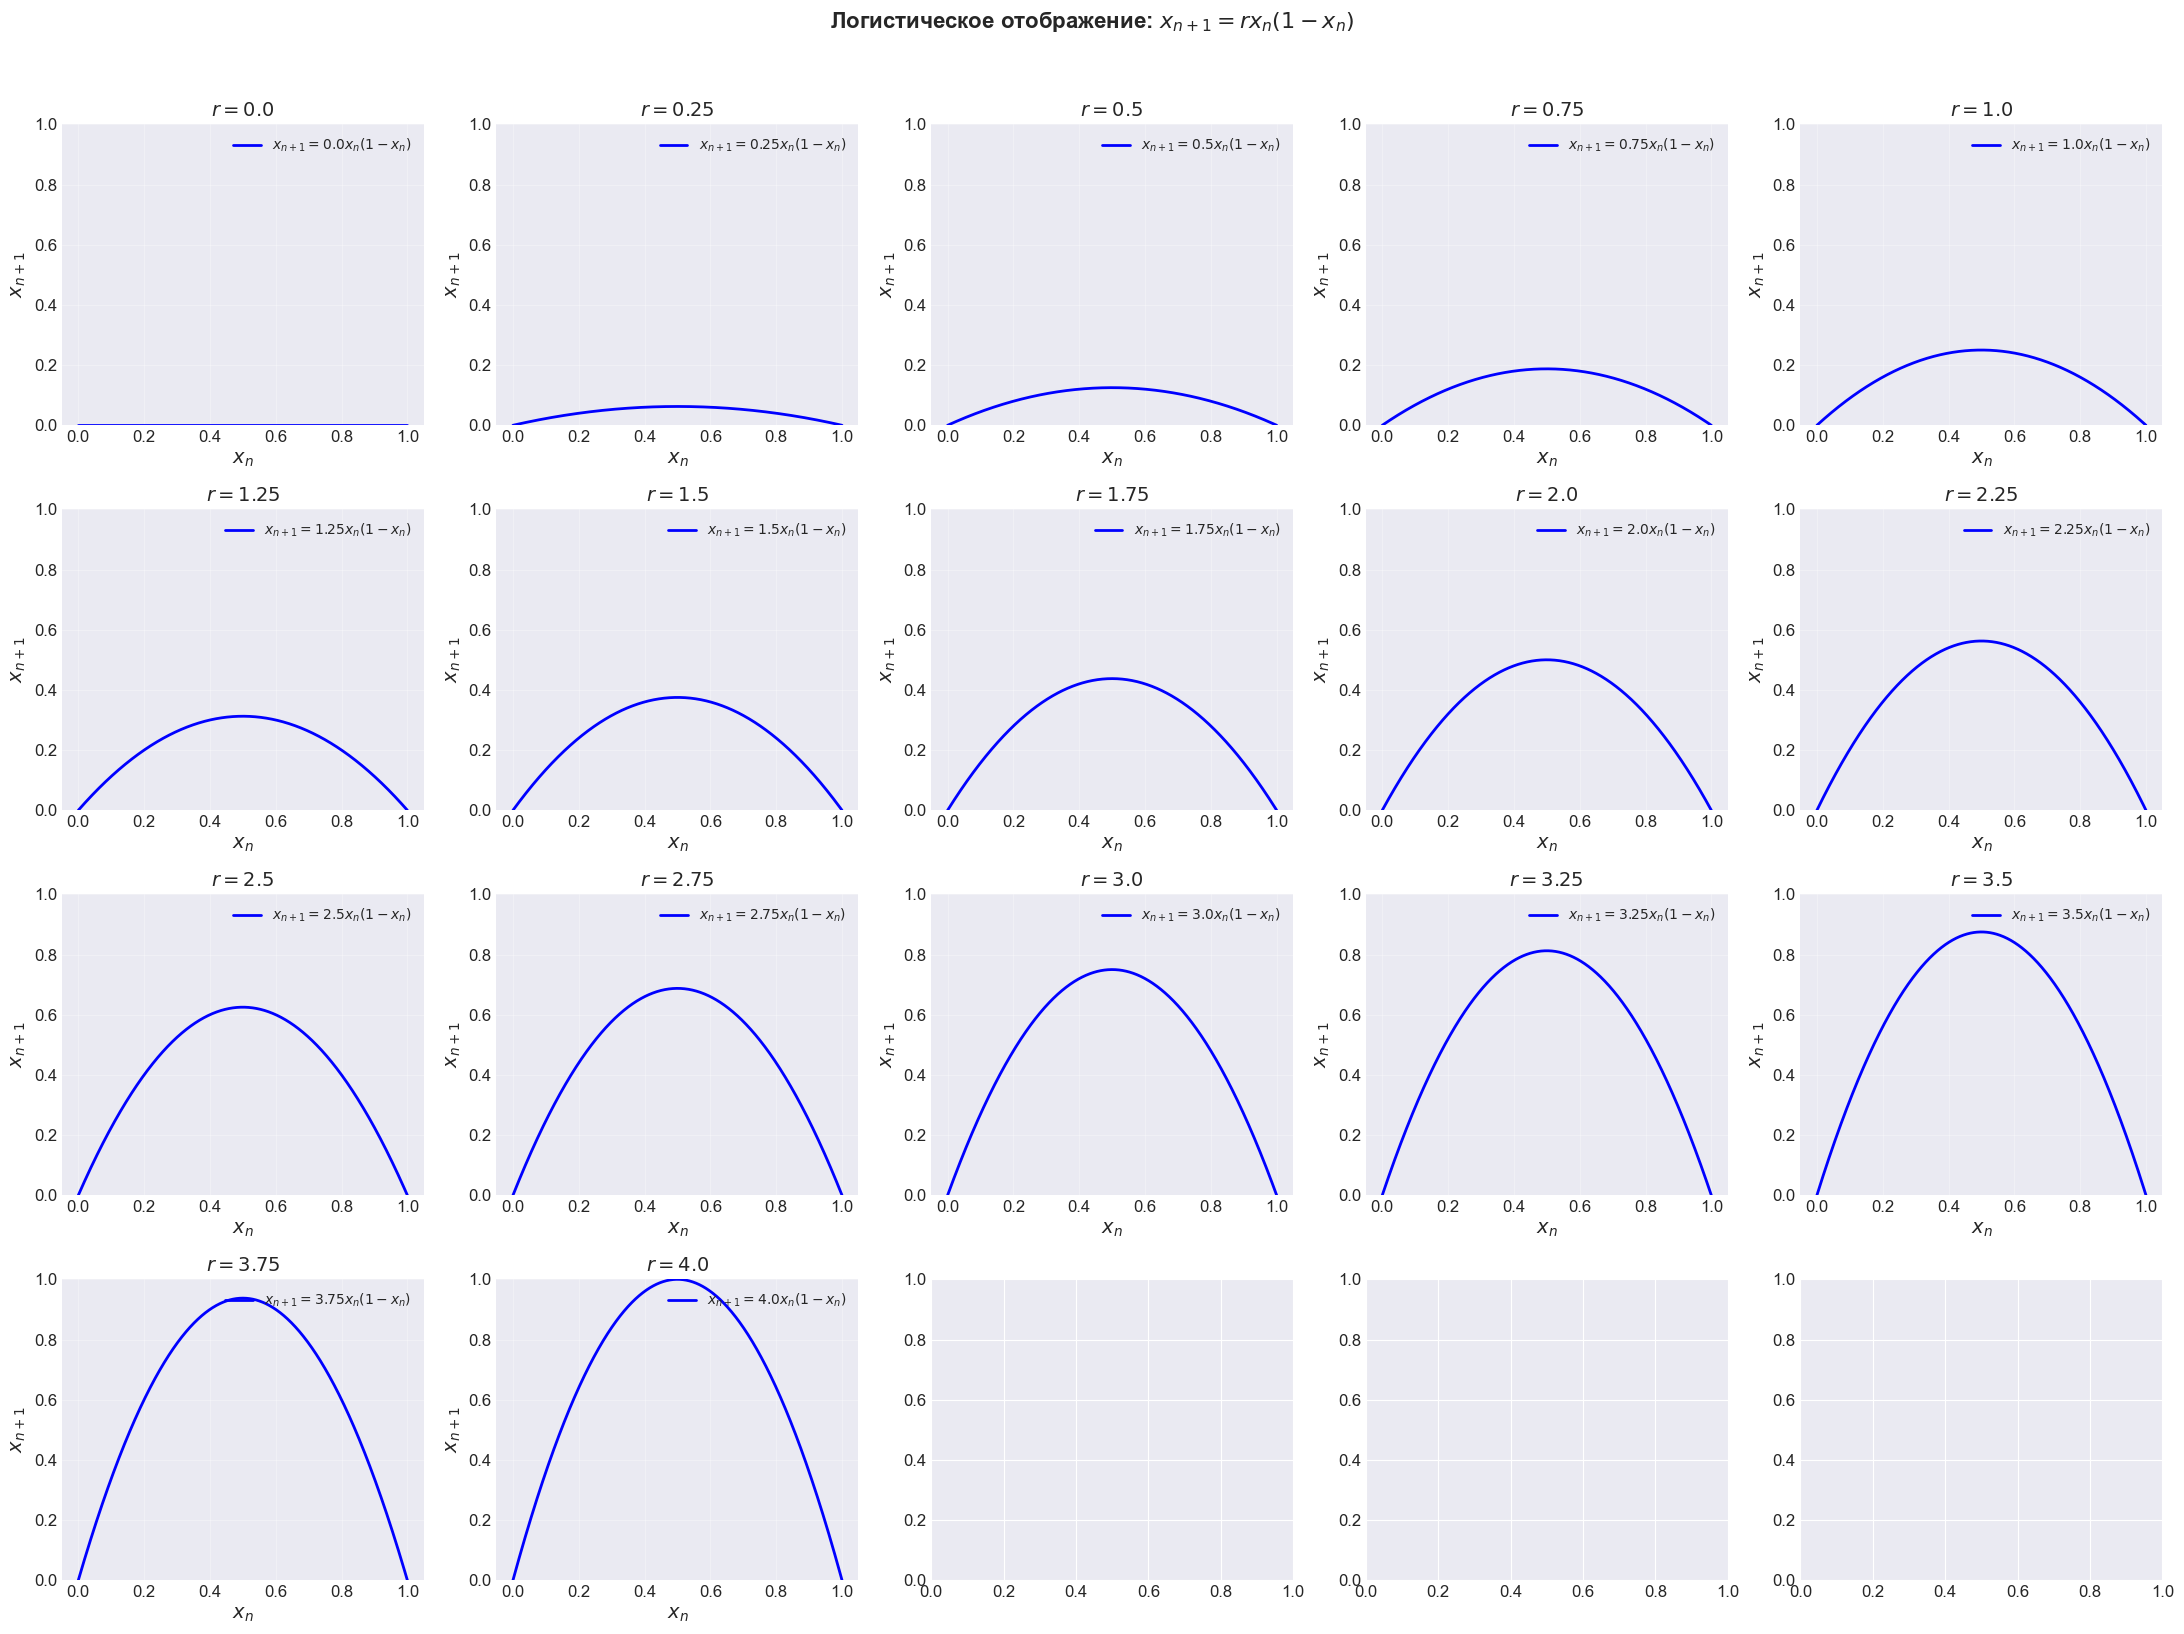

In [4]:
x0_values = np.arange(0, 1.1, 0.1)
r_values = np.arange(0, 4.25, 0.25)  # 17

len_r_values = len(r_values)

fig, axes = plt.subplots(4, 5, figsize=(22, 16))

for idx, (r, ax) in enumerate(zip(r_values, axes.flatten())):
    # Значение x от 0 до 1 с шагом 1000
    x = np.linspace(0, 1, 1000)

    # Считаем для каждого x_n x_{n+1}
    x_next = f(x, r)

    # Рисуем функцию перехода
    ax.plot(x, x_next, 'b-', linewidth=2, label=f'$x_{{n+1}} = {r}x_n(1-x_n)$')

    ax.set_ylim(0, 1)
    ax.set_xlabel('$x_n$', fontsize=14)
    ax.set_ylabel('$x_{n+1}$', fontsize=14)
    ax.set_title(f'$r = {r}$', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax.legend(loc='upper right', fontsize=10)

plt.suptitle(f.__doc__, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

$f(x) = rx(1 - x) = r(-x^2 + x) = r(-(x-\frac{1}{2})^2 + \frac{1}{4})$ - парабола с ветвями вниз c $x_0 = 0.5$ и $y_0 = \frac{r}{4}$

Параметр $r$ растягивает $f$ по оси $Y$, увеличивая её максимальное значение функции.

---

##### Easy:
Для заданной вариантом функции $g(x_n)$:
1. Постройте графики зависимости $x_n$ от $x_{n−1}$ для нескольких различных значений r.
2. Сделайте вывод о сходстве или различии поведения логистического отображения и точечного отображения. Предположите: чем могут быть вызваны сходства/различия?

---

$N = {ISU} \mod 5 = 501679 \mod 5 = 4$ - вариант лабораторной работы.
$$g(x_{n+1}) = rx_n(1 - x_n)(2 - x_n), r \in (0, \frac{3\sqrt3}{2}], x \in [0, 1]$$

In [5]:
def g(x, r):
    """Точечное отображение: $g(x_{n+1}) = rx_n(1 - x_n)(2 - x_n)$"""
    return r * x * (1 - x) * (2 - x)

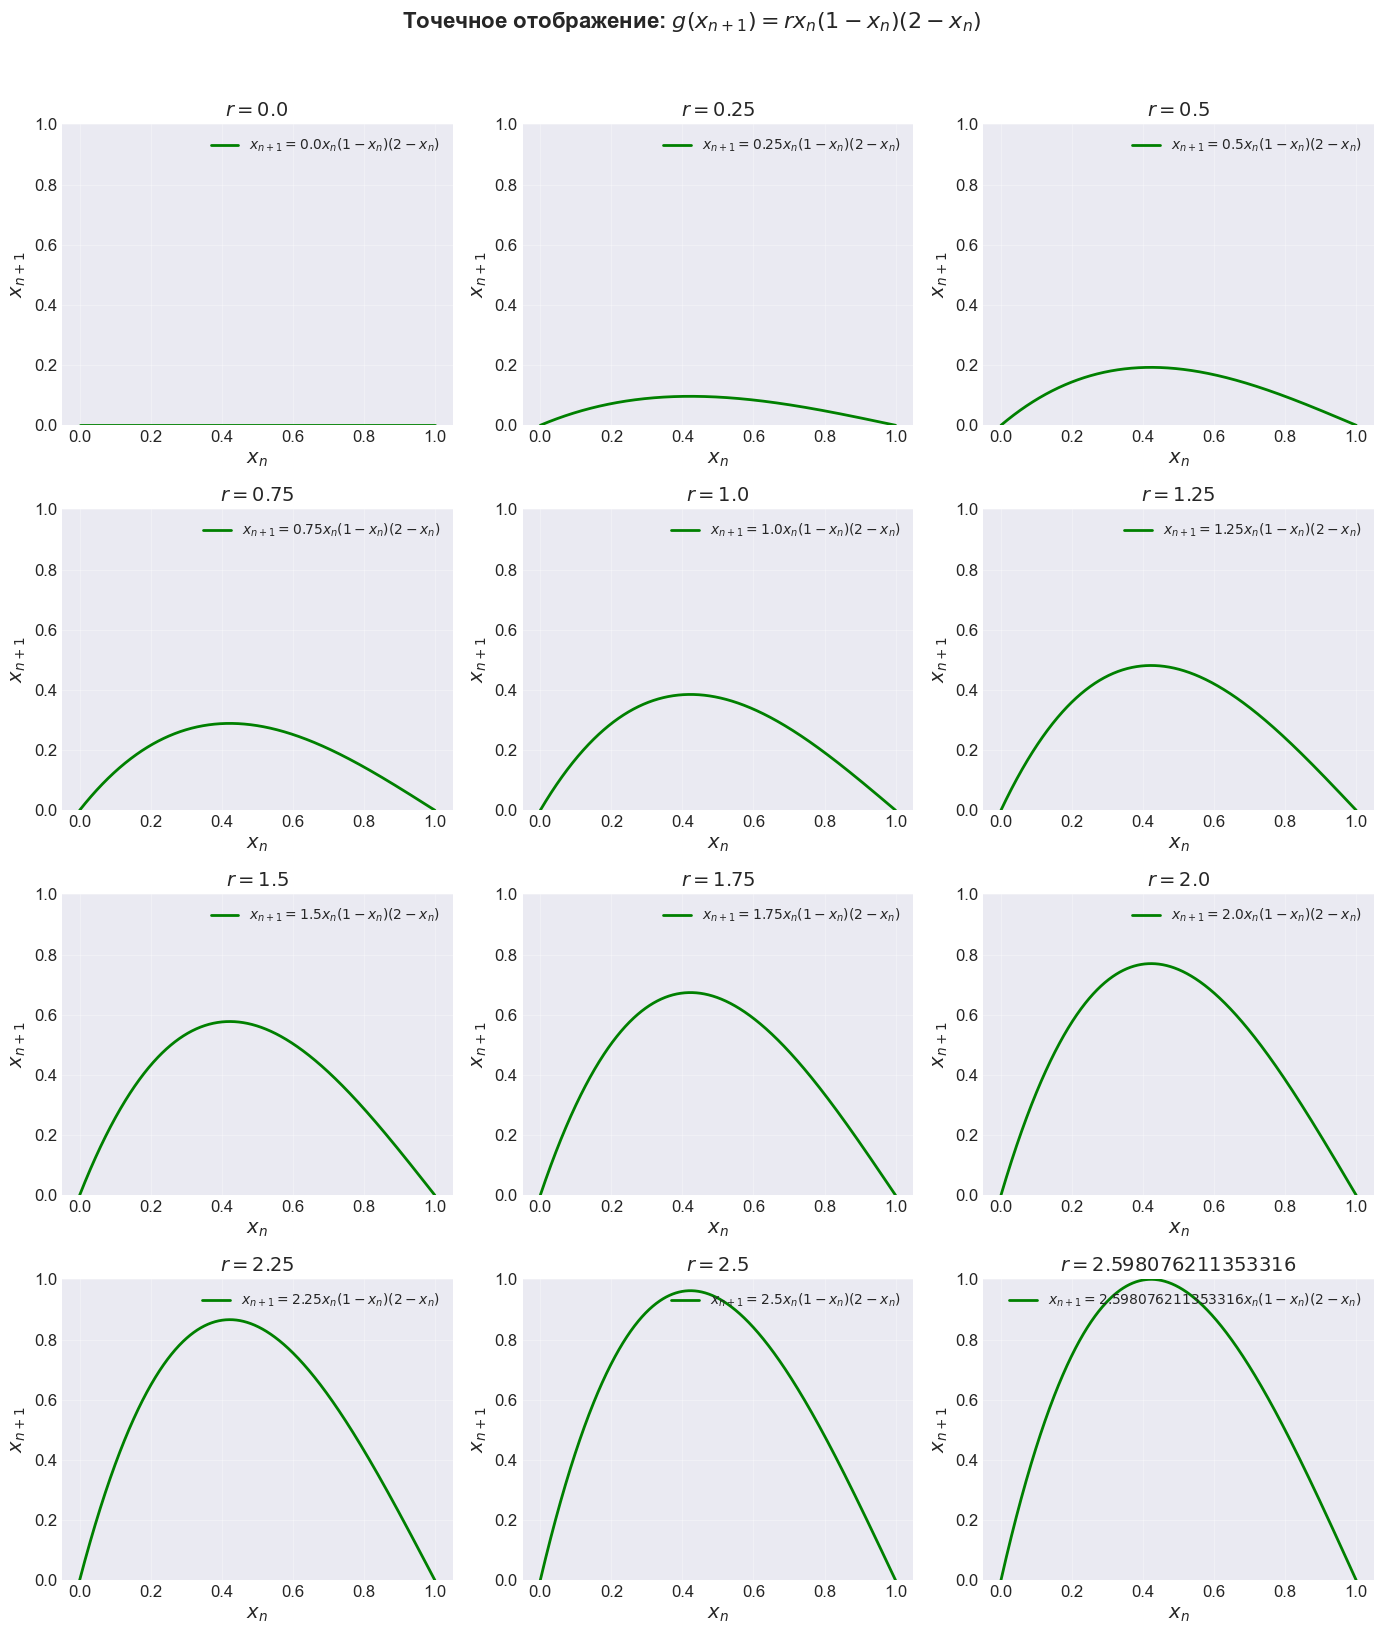

In [6]:
from math import sqrt


r_limit = 3 * sqrt(3) / 2

x0_values = np.arange(0, 1.1, 0.1)
r_values = np.arange(0, r_limit, 0.25)
r_values = np.append(r_values, r_limit)  # 12

len_r_values = len(r_values)

fig, axes = plt.subplots(4, 3, figsize=(14, 16))

for idx, (r, ax) in enumerate(zip(r_values, axes.flatten())):
    # Значение x от 0 до 1 с шагом 1000
    x = np.linspace(0, 1, 1000)

    # Считаем для каждого x_n x_{n+1}
    x_next = g(x, r)

    # Рисуем функцию перехода
    ax.plot(x, x_next, 'g-', linewidth=2, label=f'$x_{{n+1}} = {r}x_n(1-x_n)(2-x_n)$')

    ax.set_ylim(0, 1)
    ax.set_xlabel('$x_n$', fontsize=14)
    ax.set_ylabel('$x_{n+1}$', fontsize=14)
    ax.set_title(f'$r = {r}$', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax.legend(loc='upper right', fontsize=10)

plt.suptitle(g.__doc__, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

$$g(x) = rx(1 - x)(2 - x) = rx(x - 1)(x - 2) = rx(x^2 - 3x + 2) = r(x^3 - 3x^2 + 2x) \text{ — степенная функция с показателем степени 3}$$

Графики $f(x_n)$ и $g(f_n)$ довольно схожи, так как
* $g(x) = f(x)(2 - x)$, при $1 < 2 - x < 2 \Longleftrightarrow f(x) < g(x) < 2f(x)$,
* обе являются степенными функциями.

---

# Normal

**Неподвижная точка** $x^*$ переходит сама в себя под действием отображения, то есть удовлетворяет соотношению
$$x^* = f(x∗)$$

#### Normal:
1. Найдите все неподвижные точки логистического отображения.
2. При каких r отображение имеет одну неподвижную точку? Несколько?
3. Какое максимальное количество неподвижных точек может иметь логистическое отображение? Почему?

---

##### 1. Все неподвижные точки логистического отображения

Рассмотрим $x = 0$
$$f(x) = 0 \Longrightarrow \forall r:  x = 0 \text{ — неподвижная точка}$$

Рассмотрим $x \neq 0$. Пусть $x^*$ — неподвижная точка.
$$f(x^*) = rx^*(1 - x^*) = x^* \Longrightarrow x^* = 1 - \frac{1}{r}$$
$$\begin{cases}
x \in [0, 1] \\
x^* = 1 - \frac{1}{r} \\
\end{cases} \Longrightarrow \exists x^* = 1 - \frac{1}{r}, \text{ только при } r \geq 1$$

$$x =
\begin{cases}
0 \\
1 - \frac{1}{r}, r \geq 1 \\
\end{cases} \text{ — неподвижные точки}$$

##### 2. Количество неподвижный точек от $r$

Как было показано выше, количество неподвижных точек при
* $r \in [0, 1)$: одна неподвижная точка $x = 0$,
* $r \in (1, 4]$: две неподвижные точки $x = 0$ и $x = 1 - \frac{1}{r}$.

##### 3. Максимальное количество неподвижных точек

Так как $f(x)$ - парабола и система
$$\begin{cases}
f(x) = x \\
f(x) = rx(1 - x) \\
\end{cases}$$
может иметь максимум 2 решение, максимальное количество неподвижный точек тоже 2.

Для логического отображения $f(x)$ и параметров $x \in [0, 1]$ и $r \in [0, 4]$ количество неподвижных точек 1 ,либо 2.

---

#### Normal:
Докажите, что при $x_0 \in (0; 1)$ и $r \in (0; 1]$ последовательность $\{x_n\}$,заданная логистическим отображением,монотонно убывает. Существует ли предел у данной последовательности при $r \in (0; 1]$? Докажите. Покажите графически.

---

Из ранее доказанного имеем, что $\forall n \in \mathbb{N}$ выполняется $0 < x_n < 1$.

Сравним $x_n$ и $x_{n+1}$:
$$
0 < x_n < 1 \Longleftrightarrow 0 < 1 - x_n < 1
$$

$$
x_{n+1} = r \cdot x_n(1 - x_n) \leq x_n \cdot (1 - x_n) < x_n
$$

Таким образом, $\forall r \in (0; 1]$ и $\forall n \in \mathbb{N}$ выполняется:
$$
x_{n+1} < x_n
$$

Это означает, что последовательность $\{x_n\}$ **строго монотонно убывает**.

Последовательность $\{x_n\}$ обладает следующими свойствами:
1. **Монотонность:** Последовательность строго монотонно убывает (доказано выше).
2. **Ограниченность снизу:** $\forall n \in \mathbb{N} : x_n > 0$, поэтому последовательность ограничена снизу числом $0$.

Согласно теореме Вейерштрасса о пределе монотонной ограниченной последовательности, существует конечный предел:
$$
\lim_{n \to \infty} x_n = a
$$

Таким образом у последовательности $\{x_n\}$, при при $x_0 \in (0; 1)$ и $r \in (0; 1]$, существует предел. $\blacksquare$

<>:61: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:61: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/var/folders/9g/5h0d1k6d34352hd0w8nzpxxc0000gn/T/ipykernel_5276/3801207681.py:61: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  'Слева: функция перехода, Справа: траектории для $x_0 \in (0, 1)$ с шагом 0.1',


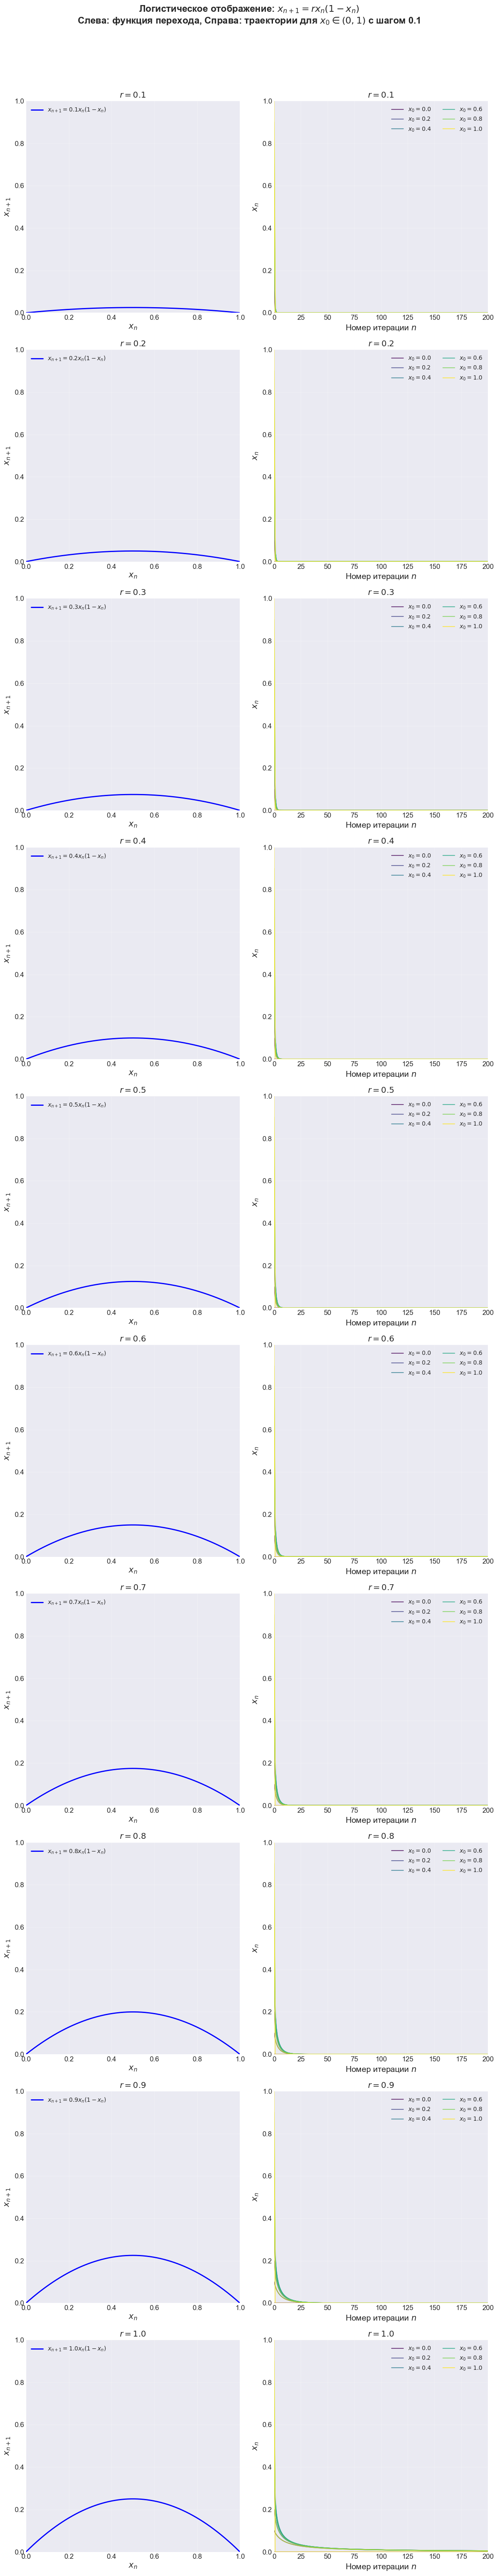

In [32]:
v0_values = np.arange(0.1, 1, 0.2)
r_values = np.arange(0.1, 1.1, 0.1)

colors = plt.cm.viridis(np.linspace(0, 1, len(x0_values)))
fig, axes = plt.subplots(len(r_values), 2, figsize=(12, 60))

for idx, r in enumerate(r_values):
    # Функция перехода
    ax_left = axes[idx, 0]

    # Значение x от 0 до 1 с шагом 1000
    x = np.linspace(0, 1, 1000)

    # Считаем для каждого x_n x_{n+1}
    x_next = f(x, r)

    # Рисуем функцию перехода
    ax_left.plot(x, x_next, 'b-', linewidth=2, label=f'$x_{{n+1}} = {r:.1f}x_n(1-x_n)$')

    # Настройки левого графика
    ax_left.set_xlim(0, 1)
    ax_left.set_ylim(0, 1)
    ax_left.set_xlabel('$x_n$', fontsize=14)
    ax_left.set_ylabel('$x_{n+1}$', fontsize=14)
    ax_left.set_title(f'$r = {r:.1f}$', fontsize=14, fontweight='bold')
    ax_left.grid(True, alpha=0.3)
    ax_left.legend(loc='upper left', fontsize=10)

    # ===== ПРАВЫЙ ГРАФИК: Траектории для разных x_0 =====
    ax_right = axes[idx, 1]

    # Строим траектории
    for x0_idx, x0 in enumerate(x0_values):
        # Генерируем траекторию
        trajectory = [x0]
        n_iterations = 200

        for i in range(n_iterations):
            next_val = f(trajectory[-1], r)
            trajectory.append(next_val)

        # Рисуем траекторию
        ax_right.plot(range(n_iterations + 1), trajectory,
                      color=colors[x0_idx],
                      alpha=0.7,
                      linewidth=1.5,
                      label=f'$x_0 = {x0:.1f}$' if x0_idx % 2 == 0 else None)

    # Настройки правого графика
    ax_right.set_xlabel('Номер итерации $n$', fontsize=14)
    ax_right.set_ylabel('$x_n$', fontsize=14)
    ax_right.set_title(f'$r = {r:.1f}$', fontsize=14, fontweight='bold')
    ax_right.set_xlim(0, n_iterations)
    ax_right.set_ylim(0, 1)
    ax_right.grid(True, alpha=0.3)

    # Добавляем легенду
    ax_right.legend(loc='upper right', fontsize=10, ncol=2)

plt.suptitle('Логистическое отображение: $x_{n+1} = rx_n(1 - x_n)$\n'
             'Слева: функция перехода, Справа: траектории для $x_0 \in (0, 1)$ с шагом 0.1',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Normal:
Для отображения $g(x_n)$, заданного вариантом:
1. Аналитически найдите неподвижную точку.
2. Найдите или оцените диапазон параметра r, при котором последовательность монотонно сходится к нулю.
3. Постройте графики зависимости $x_n$ от $n$ для нескольких различных значений параметра $r$.

---

**Неподвижная точка** удовлетворяет условию:
$$
g(x) = x
$$

##### Уравнение для неподвижных точек

Подставим выражение для $g(x)$:
$$
r x (1 - x)(2 - x) = x
$$

##### Решение уравнения

**Случай 1:** $x = 0$ — очевидное решение.

**Случай 2:** $x \neq 0$. Делим обе части на $x$:
$$
r (1 - x)(2 - x) = 1
$$

Раскроем скобки:
$$
r (2 - 3x + x^2) = 1
$$

Получили квадратное уравнение относительно $x$:
$$
r x^2 - 3r x + 2r - 1 = 0
$$

##### Решение квадратного уравнения

Дискриминант:
$$
D = (-3r)^2 - 4 \cdot r \cdot (2r - 1) = 9r^2 - 8r^2 + 4r = r^2 + 4r
$$

Корни:
$$
x_{1,2} = \frac{3r \pm \sqrt{r^2 + 4r}}{2r}
$$

##### Анализ корней

1. **Корень со знаком "+":**
   $$
   x_1 = \frac{3r + \sqrt{r^2 + 4r}}{2r}
   $$
   Заметим, что $\sqrt{r^2 + 4r} > r$ при $r > 0$, поэтому:
   $$
   x_1 > \frac{3r + r}{2r} = \frac{4r}{2r} = 2
   $$
   Этот корень не принадлежит интервалу $(0, 1)$.

2. **Корень со знаком "-":**
   $$
   x_2 = \frac{3r - \sqrt{r^2 + 4r}}{2r}
   $$
   Проверим, принадлежит ли он интервалу $(0, 1)$:

   - **Нижняя граница:** $x_2 > 0$ при условии:
     $$
     3r > \sqrt{r^2 + 4r} \Rightarrow 9r^2 > r^2 + 4r \Rightarrow 8r^2 > 4r \Rightarrow 2r > 1 \Rightarrow r > \frac{1}{2}
     $$

   - **Верхняя граница:** $x_2 < 1$:
     $$
     \frac{3r - \sqrt{r^2 + 4r}}{2r} < 1 \Rightarrow 3r - \sqrt{r^2 + 4r} < 2r \Rightarrow r < \sqrt{r^2 + 4r}
     $$
     Это неравенство выполняется при всех $r > 0$.

##### Итог по неподвижным точкам

1. **При любом $r > 0$:** существует неподвижная точка $x = 0$.

2. **При $r > \frac{1}{2}$:** появляется вторая неподвижная точка:
   $$
   x^* = \frac{3r - \sqrt{r^2 + 4r}}{2r} \in (0, 1)
   $$

3. **При $r = \frac{1}{2}$:** $x^* = 0$, то есть обе неподвижные точки сливаются.

---

##### Условие монотонной сходимости к нулю

Для того чтобы последовательность $x_{n+1} = g(x_n)$ монотонно сходилась к $0$, необходимо и достаточно, чтобы:

1. $0 < g(x) < x$ для всех $x \in (0, 1)$.
2. Единственной неподвижной точкой в $[0, 1]$ является $x = 0$.

##### Исследование неравенства $g(x) < x$

Рассмотрим:
$$
g(x) < x \quad \Rightarrow \quad r x (1 - x)(2 - x) < x
$$

При $x > 0$ делим обе части на $x$:
$$
r (1 - x)(2 - x) < 1
$$

Обозначим:
$$
h(x) = r (1 - x)(2 - x)
$$

Требуется, чтобы $h(x) < 1$ для всех $x \in (0, 1)$.

##### Анализ функции $h(x)$ на $(0, 1)$

Функция $h(x)$ является квадратичной:
$$
h(x) = r (x^2 - 3x + 2)
$$

Её производная:
$$
h'(x) = r (2x - 3)
$$

Критическая точка: $x = \frac{3}{2}$, но она не принадлежит интервалу $(0, 1)$.

На интервале $(0, 1)$ функция $h(x)$ монотонно убывает (так как $h'(x) < 0$ для $x < \frac{3}{2}$).

Значения на границах:
- $h(0) = 2r$
- $h(1) = 0$

##### Условие $h(x) < 1$ для всех $x \in (0, 1)$

Поскольку $h(x)$ монотонно убывает, её максимум на $(0, 1)$ достигается в точке $x = 0$:
$$
\max_{x \in [0, 1]} h(x) = h(0) = 2r
$$

Следовательно, условие $h(x) < 1$ для всех $x \in (0, 1)$ равносильно:
$$
2r < 1 \quad \Rightarrow \quad r < \frac{1}{2}
$$

При $r = \frac{1}{2}$:
- $h(0) = 1$, но для любого $x > 0$: $h(x) < 1$
- Последовательность по-прежнему будет монотонно убывать к $0$, но скорость сходимости будет медленнее

##### Проверка отсутствия других неподвижных точек

Как было показано в Части 1:
- При $r \leq \frac{1}{2}$ вторая неподвижная точка $x^*$ либо не существует ($r < \frac{1}{2}$), либо совпадает с $0$ ($r = \frac{1}{2}$).
- Следовательно, единственной неподвижной точкой в $[0, 1]$ является $x = 0$.

##### Выводы

Неподвижные точки:
- При всех $r > 0$: $x = 0$ — неподвижная точка.
- При $r > \frac{1}{2}$: дополнительная неподвижная точка $x^* = \dfrac{3r - \sqrt{r^2 + 4r}}{2r} \in (0, 1)$.


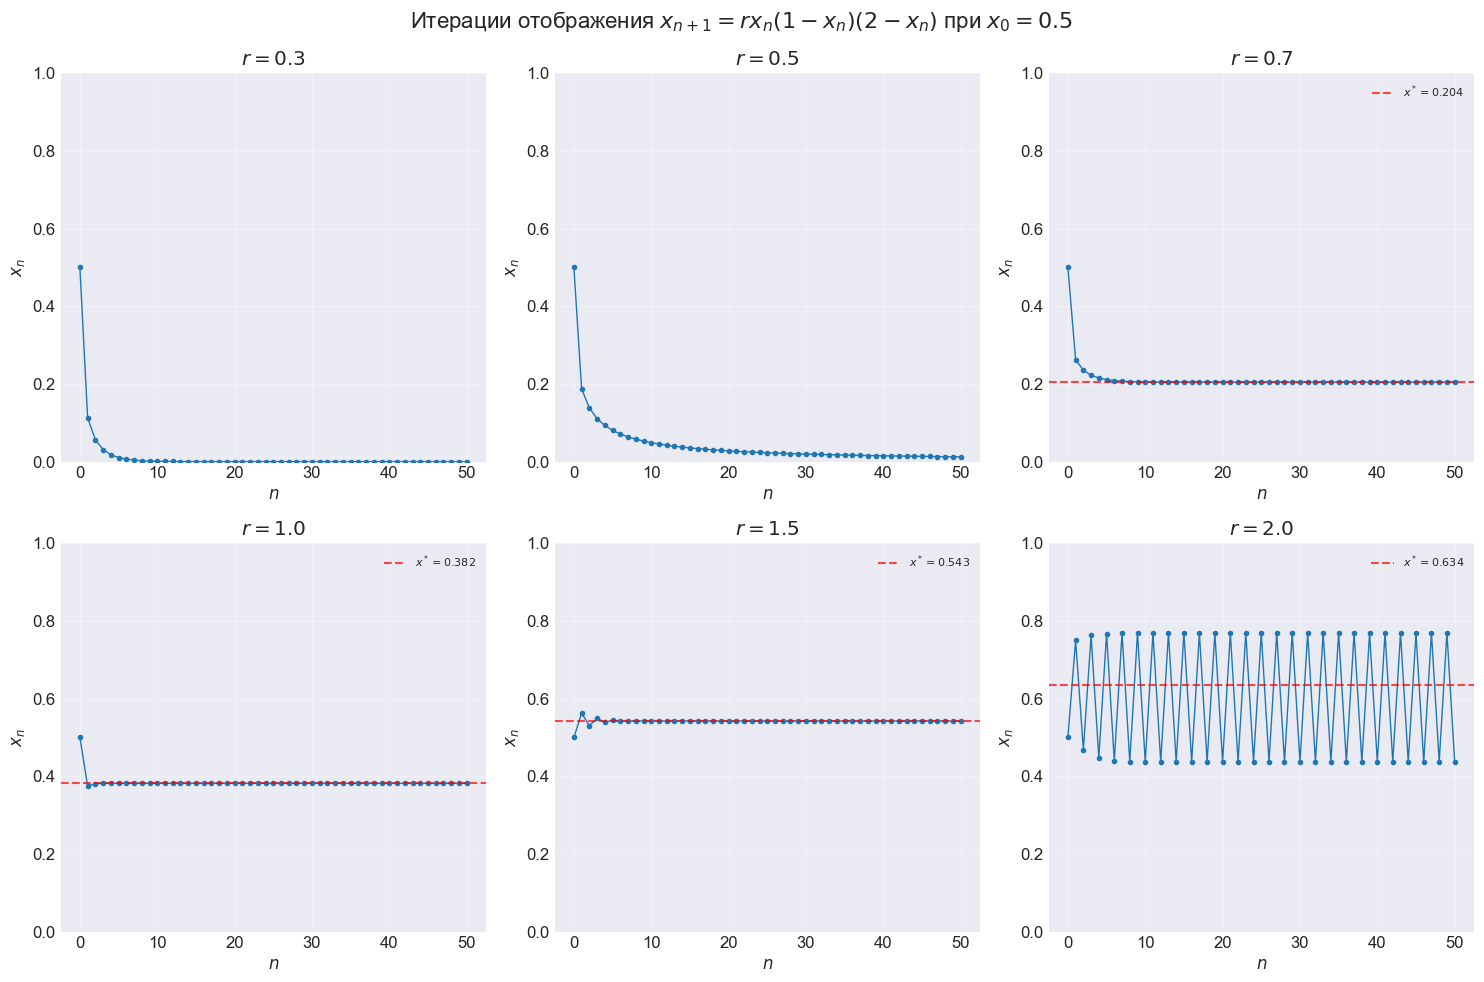

In [36]:
x0 = 0.5
n_iter = 50

# Различные значения параметра r
r_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, r in enumerate(r_values):
    x_sequence = [x0]

    for i in range(n_iter):
        x_sequence.append(g(x_sequence[-1], r))

    ax = axes[idx]
    ax.plot(range(n_iter + 1), x_sequence, 'o-', markersize=3, linewidth=1)
    ax.set_xlabel('$n$')
    ax.set_ylabel('$x_n$')
    ax.set_title(f'$r = {r}$')
    ax.grid(True, alpha=0.3)

    # Отмечаем ненулевую неподвижную точку, если она существует и лежит в (0,1)
    if r > 0.5:
        x_star = (3 * r - np.sqrt(r * (r + 4))) / (2 * r)
        if 0 <= x_star <= 1:
            ax.axhline(y=x_star, color='red', linestyle='--', alpha=0.7,
                       label=f'$x^* = {x_star:.3f}$')
            ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('Итерации отображения $x_{n+1} = r x_n (1 - x_n)(2 - x_n)$ при $x_0 = 0.5$',
             fontsize=16)
plt.tight_layout()
plt.show()

# Hard

# Expert


Найдём точку максимального значения $g(x) = y_0$, при $x \in [0, 1]$:

$$g'(x) = r(3x^2 - 6x + 2) = r(3(x - 2x + 1) - 1) = r(3(x - 1)^2 - 1)$$
$$g'(x_0) = 0 \text{, где } x_0 \text{ — точка перегиба}$$
$$g'(x_0) = r(3(x_0 - 1)^2 - 1) = 0 \Longrightarrow x_0 = 1 \pm\frac{\sqrt{3}}{3}$$
$$\begin{cases}
    x_0 = \pm\frac{\sqrt{3}}{3} + 1 \\
    x \in [0,1] \\
\end{cases} \Longrightarrow x_0 = 1 - \frac{\sqrt{3}}{3} \Longrightarrow y_0 = \frac{2\sqrt{3}r}{9}$$

Поведение функции в зависимости от $r \in (0, 4]$:
* При $r <= 1$, $f$ независимо от $x_0$ стремиться к 0
* При $r \in (1, 3)$, $f$ стремится к стабильной точке $1 - \frac{1}{r}$
* При $r \in [3, \thickapprox3.57)$, $f$ образует цикл
* При $r \in [\thickapprox3.57, 4]$, $f$ ведёт себя хаотично